In [84]:
import pandas as pd

In [85]:
df = pd.read_csv('laptop_price.csv',encoding='latin1')

In [86]:
print("First 5 rows of the DataFrame:")
print(df.head())
print("\nConcise summary of the DataFrame:")
df.info()
print("\nDescriptive statistics for numerical columns:")
print(df.describe())
print("\nMissing values in each column:")
print(df.isnull().sum())

First 5 rows of the DataFrame:
   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1          2   Apple  Macbook Air  Ultrabook    13.3   
2          3      HP       250 G6   Notebook    15.6   
3          4   Apple  MacBook Pro  Ultrabook    15.4   
4          5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution                         Cpu   Ram  \
0  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz   8GB   
1                            1440x900        Intel Core i5 1.8GHz   8GB   
2                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz   8GB   
3  IPS Panel Retina Display 2880x1800        Intel Core i7 2.7GHz  16GB   
4  IPS Panel Retina Display 2560x1600        Intel Core i5 3.1GHz   8GB   

                Memory                           Gpu  OpSys  Weight  \
0            128GB SSD  Intel Iris Plus Graphics 640  macOS  1.37kg   
1  128GB Flash Storage        Intel HD 

# Handling Categorical Features
Identify and preprocess categorical features in the dataset, including converting 'Ram' and 'Weight' to numerical types, and applying one-hot encoding to suitable nominal categories.


In [87]:
import numpy as np

# 1. Convert 'Ram' column to numerical
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
print("Converted 'Ram' to numerical type.")

# 2. Convert 'Weight' column to numerical
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)
print("Converted 'Weight' to numerical type.")

# 3. Identify categorical columns for one-hot encoding
categorical_cols = ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys']

# 4. Apply one-hot encoding to identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Applied one-hot encoding to categorical columns.")

# 5. Drop 'laptop_ID' and 'Product' columns
df_encoded = df_encoded.drop(columns=['laptop_ID', 'Product'])
print("Dropped 'laptop_ID' and 'Product' columns.")

print("\nFirst 5 rows of the preprocessed DataFrame:")
print(df_encoded.head())
print("\nInformation of the preprocessed DataFrame:")
df_encoded.info()

Converted 'Ram' to numerical type.
Converted 'Weight' to numerical type.
Applied one-hot encoding to categorical columns.
Dropped 'laptop_ID' and 'Product' columns.

First 5 rows of the preprocessed DataFrame:
   Inches  Ram  Weight  Price_euros  Company_Apple  Company_Asus  \
0    13.3    8    1.37      1339.69           True         False   
1    13.3    8    1.34       898.94           True         False   
2    15.6    8    1.86       575.00          False         False   
3    15.4   16    1.83      2537.45           True         False   
4    13.3    8    1.37      1803.60           True         False   

   Company_Chuwi  Company_Dell  Company_Fujitsu  Company_Google  ...  \
0          False         False            False           False  ...   
1          False         False            False           False  ...   
2          False         False            False           False  ...   
3          False         False            False           False  ...   
4          False     

## Feature Scaling

Apply feature scaling to numerical features using a technique like StandardScaler.


In [88]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features to scale
numerical_features = ['Inches', 'Ram', 'Weight']

# Create a StandardScaler instance
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print("Numerical features 'Inches', 'Ram', and 'Weight' have been scaled.")
print("\nFirst 5 rows of the DataFrame with scaled numerical features:")
print(df_encoded.head())
print("\nDescriptive statistics for scaled numerical columns:")
print(df_encoded[numerical_features].describe())

Numerical features 'Inches', 'Ram', and 'Weight' have been scaled.

First 5 rows of the DataFrame with scaled numerical features:
     Inches       Ram    Weight  Price_euros  Company_Apple  Company_Asus  \
0 -1.204407 -0.075195 -1.005283      1339.69           True         False   
1 -1.204407 -0.075195 -1.050381       898.94           True         False   
2  0.408772 -0.075195 -0.268684       575.00          False         False   
3  0.268495  1.498767 -0.313782      2537.45           True         False   
4 -1.204407 -0.075195 -1.005283      1803.60           True         False   

   Company_Chuwi  Company_Dell  Company_Fujitsu  Company_Google  ...  \
0          False         False            False           False  ...   
1          False         False            False           False  ...   
2          False         False            False           False  ...   
3          False         False            False           False  ...   
4          False         False            False

## Split Data into Training and Test Sets

Divide the preprocessed dataset into training and testing sets. The training set will be used to train the ANN model, and the test set will be used to evaluate its performance on unseen data, ensuring the model generalizes well.


In [89]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) from the target variable (y)
X = df_encoded.drop('Price_euros', axis=1)
y = df_encoded['Price_euros']
print("Separated features (X) and target variable (y).")

# 2. Split the features (X) and target (y) into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Split data into training and testing sets.")

# 3. Print the shapes of X_train, X_test, y_train, and y_test
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Separated features (X) and target variable (y).
Split data into training and testing sets.

Shape of X_train: (1042, 337)
Shape of X_test: (261, 337)
Shape of y_train: (1042,)
Shape of y_test: (261,)


## Build the Artificial Neural Network (ANN) Model

Design and build a simple sequential ANN model using TensorFlow/Keras. This step will involve defining the input layer, hidden layers with appropriate activation functions (e.g., ReLU), and an output layer suitable for predicting laptop prices (a regression task).


# **Importing the ANN Toolbox**
To build our neural network, we use TensorFlow and Keras. Think of these as the building blocks for our model's "brain."

**Sequential:** This is the container. It lets us stack layers one after the other, like building with Lego blocks.

**Dense:** These are the actual layers of neurons. A "Dense" layer means every neuron is connected to every neuron in the next layer.

**Dropout:** This is a "safety" tool. It randomly turns off some neurons during training to prevent the model from getting too "lazy" or just memorizing the answers (Overfitting).

**EarlyStopping:** This tells the computer: "Stop training once the model stops getting better." It saves time and prevents the model from getting worse over time.

In [90]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.regularizers import l2

**Step 1: Initialize a Sequential model instance**                          

This line creates an empty **"container."** Think of it as a blank stack where we will **layer our neurons one by one in a straight line from start to finish.**

In [91]:
# 1. Initialize a Sequential model instance
model = Sequential()

**Step 2: Adding the Input Layer**

**input_dim:** This tells the model how many features (columns) are in your data so it knows what to expect.

**Dense(units=128):** We are adding 128 neurons. These neurons will look for patterns in your data.

**activation='relu':** This is the "logic gate." It helps the model learn complex patterns by turning off negative signals and keeping positive ones.

**Dropout(0.2):** To prevent cheating (overfitting), we randomly "turn off" 20% of the neurons during training. This makes the model more robust.

In [92]:
# 2. Add the input layer
# The input_shape should match the number of features in X_train
input_dim = X_train.shape[1]
model.add(Dense(units=128, activation='relu', input_shape=(input_dim,))) #kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
print(f"Input layer added with {input_dim} features and 128 units.")

Input layer added with 337 features and 128 units.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Step 3: Adding Hidden Layers**                                                     
This is where the actual **"learning"** happens. We are adding three hidden layers to make the model deeper and smarter.

**Layer Stack (128 → 64 → 32):** We gradually reduce the number of neurons. This helps the model summarize the information and focus on the most important patterns.

**activation='relu':** Used in every layer to help the model learn non-linear, complex relationships in your data.

**Dropout(0.2):** Again, we disable 20% of neurons in each step. This forces the remaining neurons to work harder and prevents the model from relying too much on any single connection.

In [93]:

# 3. Add one or more hidden layers
model.add(Dense(units=128, activation='relu'))  #kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
model.add(Dense(units=64, activation='relu'))#kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))#kernel_regularizer=l2(0.001)
model.add(Dropout(0.2))
print("Hidden layers added.")

Hidden layers added.


**Step 4: The Output Layer**

**units=1:** Since we are predicting a single numerical value **(Regression)**, we only need one output neuron.

**activation='linear':** This means the model will output the raw number directly **(like a price, temperature, or score)** without squashing it between 0 and 1.

In [94]:
# 4. Add the output layer for regression
# 1 neuron for a single regression output (price prediction), no activation function (linear output)
model.add(Dense(units=1, activation='linear'))
print("Output layer added.")

Output layer added.


**Step 5: Final Review & Safety Settings**                                                   
Before we start training, we check our work and set a **"safety switch."**

Model Summary
**model.summary()** prints a table showing every layer we created. It helps us confirm the number of neurons and the total Parameters **(the connections the model needs to learn)**.

In [95]:
# 5. Print the model summary
print("\nANN Model Summary:")
model.summary()




ANN Model Summary:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,145 (274.00 KB)

 Trainable params: 70,145 (274.00 KB)

 Non-trainable params: 0 (0.00 B)

**EarlyStopping**
------------------

It prevents **Overfitting**. Instead of guessing how many rounds to train for, this tool stops the training at the **"sweet spot"** exactly before the model starts memorizing the data rather than learning it.



**monitor='val_loss':** It watches the model's error rate on new data.

**patience=10:** It gives the model 10 chances to improve. If the model doesn't get better after 10 rounds **(epochs)**, it stops automatically.

**verbose=1:** It prints a message in your notebook telling you exactly when and why it stopped.

In [96]:
early = EarlyStopping(monitor='val_loss', mode='auto', verbose=1, patience=10)

Now that we’ve built the **"brain"** we need to tell it how to learn and how to measure its own success.

**Optimizer:** This is the "coach." It tells the model how to update its internal settings to reduce errors. (The Adam optimizer is the most popular choice).

**Loss Function:** This calculates the "penalty." It measures how far off the model's prediction was from the actual answer.

**Metrics:** This is the "scoreboard." It helps us track how well the model is performing in a way we can easily understand (like MAE or MSE).

In [97]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
print("ANN model compiled with Adam optimizer, Mean Squared Error loss, and Mean Absolute Error metric.")

ANN model compiled with Adam optimizer, Mean Squared Error loss, and Mean Absolute Error metric.


Now it's time to actually **"train"** the brain. We pass our data through the model so it can learn the patterns.

**X_train & y_train:** These are the "questions" and the "correct answers" we use to teach the model.

**Epochs:** This is the number of times the model will go through the entire dataset. Think of it as study rounds.

**Validation Data:** We set aside a small piece of data to test the model after each round to see if it’s actually learning or just memorizing.

**Callbacks:** We plug in our EarlyStopping here to make sure the model stops training as soon as it reaches its peak performance.

In [98]:
print("Starting model training...")
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1,callbacks=[early])
print("Model training complete.")

Starting model training...
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1801054.7500 - mean_absolute_error: 1138.9769 - val_loss: 1746941.1250 - val_mean_absolute_error: 1136.5204
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1641947.1250 - mean_absolute_error: 1088.1783 - val_loss: 1450087.6250 - val_mean_absolute_error: 1002.3967
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1124407.0000 - mean_absolute_error: 826.7528 - val_loss: 348061.9688 - val_mean_absolute_error: 486.2719
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 369649.3438 - mean_absolute_error: 504.1726 - val_loss: 236379.3438 - val_mean_absolute_error: 310.0927
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 211884.4688 - mean_absolute_error: 306.7885 - val_loss: 175923.9688 - val_mean_absolute_error: 294.0413
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 189562.9844 - mean_absolute_error: 309.1074 - val_loss: 167090.5625 - val_mean_absolute_e

**Making Predictions**
---------------------

Now that the model is trained, we put it to the test using data it has never seen before.

In [99]:
y_pred = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [100]:
y_pred_train = model.predict(X_train)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [107]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

#Testing - Evaluation
# Calculate Mean Squared Error (MSE) and Mean Absolute Error (MAE)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print(f"Testing Mean Squared Error (MSE): {mse}")
print(f"Testing Mean Absolute Error (MAE): {mae}")
print(f"Testing R2 Score: {r2_score}")

Testing Mean Squared Error (MSE): 76726.64567168472
Testing Mean Absolute Error (MAE): 177.93561044978
Testing R2 Score: 0.8489414473740217


In [105]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

#Training - Evaluation
mse = mean_squared_error(y_train, model.predict(X_train))
mae = mean_absolute_error(y_train, model.predict(X_train))
r2_score = r2_score(y_train, model.predict(X_train))

print(f"Training Mean Squared Error (MSE): {mse}")
print(f"Training Mean Absolute Error (MAE): {mae}")
print(f"Training R2 Score: {r2_score}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Training Mean Squared Error (MSE): 46611.695982243684
Training Mean Absolute Error (MAE): 138.82100296752697
Training R2 Score: 0.9035351835591252


## **Visualize Training and Validation Loss**

Now, we create a plot to see how the model performed during its "study sessions" (epochs).

Training Loss: Shows how well the model learned the training data.

Validation Loss: Shows how well the model performed on new, unseen data.

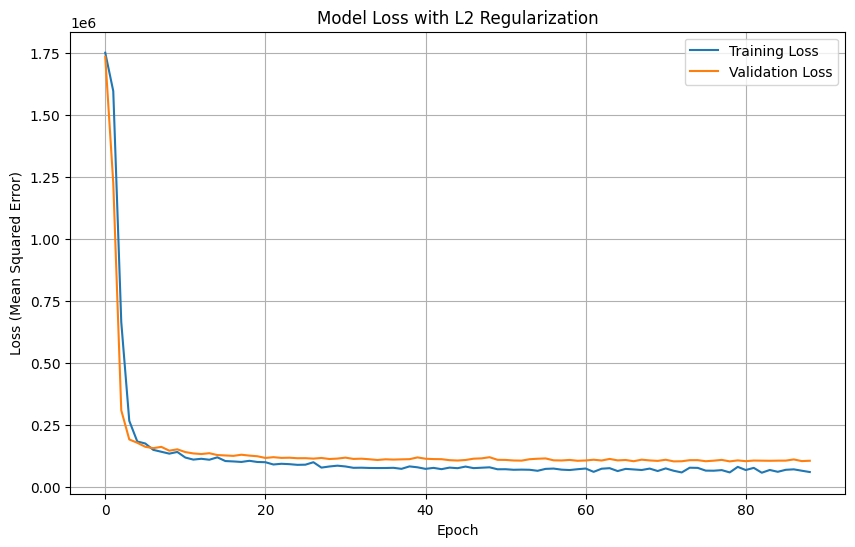

Plot of training and validation loss displayed.


In [103]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history_regularized.history['loss'], label='Training Loss')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss')
plt.title('Model Loss with L2 Regularization')
plt.ylabel('Loss (Mean Squared Error)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print("Plot of training and validation loss displayed.")

In [ ]:
import pickle

# To SAVE the model/history
with open('ann_model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
# To LOAD the model back
# with open('ann_model.pkl', 'rb') as file:
#     loaded_model = pickle.load(file)